Running Experiment 1: Adam Optimizer...
Adam | Epoch 1 | Loss: 0.2617 | Acc: 92.03%
Adam | Epoch 2 | Loss: 0.0963 | Acc: 97.09%
Adam | Epoch 3 | Loss: 0.0741 | Acc: 97.79%
Adam | Epoch 4 | Loss: 0.0574 | Acc: 98.29%
Adam | Epoch 5 | Loss: 0.0502 | Acc: 98.39%

Running Experiment 2: SGD Optimizer...
SGD | Epoch 1 | Loss: 0.8152 | Acc: 74.34%
SGD | Epoch 2 | Loss: 0.3040 | Acc: 90.76%
SGD | Epoch 3 | Loss: 0.2153 | Acc: 93.58%
SGD | Epoch 4 | Loss: 0.1717 | Acc: 94.88%
SGD | Epoch 5 | Loss: 0.1481 | Acc: 95.59%


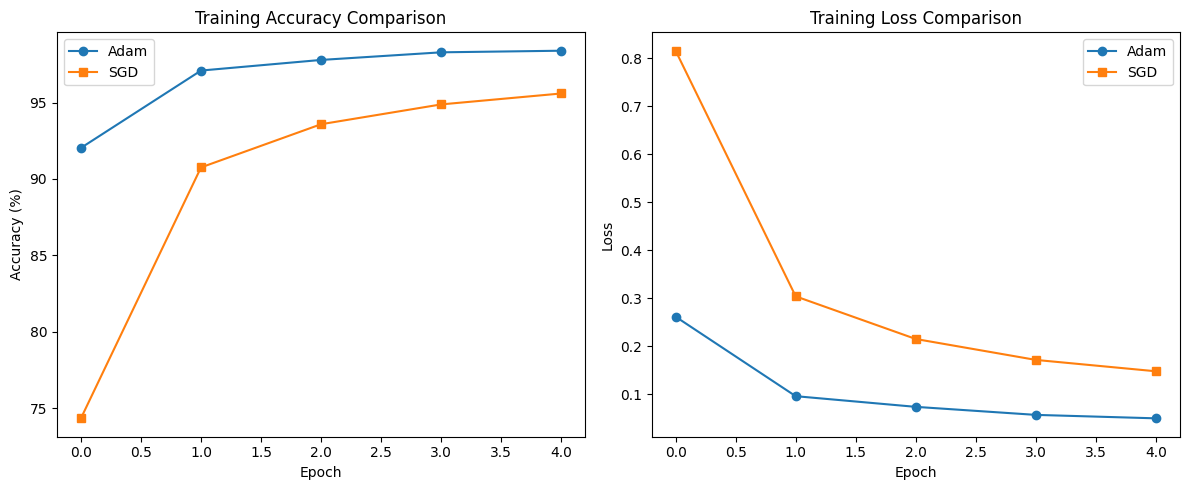


--- Project Results Comparison ---
Model (Optimizer) Final Accuracy Final Loss
       CNN (Adam)         98.39%     0.0502
        CNN (SGD)         95.59%     0.1481


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd

# ===== 1) Data Preprocessing (تحقيق بند 2) =====
# Normalization (0.1307, 0.3081) is specific to MNIST for better performance
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Loading Dataset (بند 1)
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Partitioning (بند 2)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

# ===== 2) CNN Model Architecture (تحقيق بند 3 و 4) =====
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Multiple hidden layers (بند 3)
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3)

        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.dropout = nn.Dropout(0.5) # Model Enhancement (بند 4)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ===== 3) Train Function (تحقيق بند 5 و 6) =====
def train_model(optimizer_name):
    model = CNN()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    epoch_losses = []
    epoch_accuracies = []

    for epoch in range(5):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        epoch_losses.append(total_loss / len(train_loader))
        epoch_accuracies.append(acc)

        print(f"{optimizer_name} | Epoch {epoch+1} | Loss: {epoch_losses[-1]:.4f} | Acc: {acc:.2f}%")

    return model, epoch_losses, epoch_accuracies

# ===== 4) Running Experiments (تحقيق بند 7) =====
print("Running Experiment 1: Adam Optimizer...")
model_adam, loss_adam, acc_adam = train_model("Adam")

print("\nRunning Experiment 2: SGD Optimizer...")
model_sgd, loss_sgd, acc_sgd = train_model("SGD")

# ===== 5) Visualization (تحقيق بند 8) =====
plt.figure(figsize=(12, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(acc_adam, label='Adam', marker='o')
plt.plot(acc_sgd, label='SGD', marker='s')
plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(loss_adam, label='Adam', marker='o')
plt.plot(loss_sgd, label='SGD', marker='s')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# ===== 6) Results Table (تحقيق بند 9) =====
results = pd.DataFrame({
    'Model (Optimizer)': ['CNN (Adam)', 'CNN (SGD)'],
    'Final Accuracy': [f"{acc_adam[-1]:.2f}%", f"{acc_sgd[-1]:.2f}%"],
    'Final Loss': [f"{loss_adam[-1]:.4f}", f"{loss_sgd[-1]:.4f}"]
})

print("\n--- Project Results Comparison ---")
print(results.to_string(index=False))